# Exploratory Data Analysis (EDA)

In [1]:
!pip install nltk


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install wordcloud


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries for NLP
import re
import string
from wordcloud import WordCloud
from collections import Counter
from sklearn.utils import resample
import nltk
from nltk.corpus import stopwords
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.stem import PorterStemmer

In [4]:
# Initializing NLTK
nltk.download('stopwords')
nltk.download('punkt')
STOP_WORDS = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Jawad\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Jawad\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


**1. Loading the Dataset**

In [5]:
df = pd.read_excel('Sentiment_Analysis_Dataset.xlsx')

In [6]:
df.head()

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


In [7]:
df.columns = [col.capitalize() for col in df.columns]

In [8]:
# Display the resulting column names and the first few rows
print("Updated Column Names:", df.columns.tolist())

Updated Column Names: ['Title', 'Rating', 'Body']


In [9]:
df.head()

,Title,Rating,Body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


In [10]:
df.shape

(1440, 3)

In [11]:
# Pre-processing: Map Rating to Sentiment and rename columns for clarity
# 1-2: Negative, 3: Neutral, 4-5: Positive

df['Review_Text'] = df['Body'].astype(str)

In [12]:
def map_sentiment(rating):
    if rating <= 2: return 'Negative'
    elif rating == 3: return 'Neutral'
    else: return 'Positive'

df['Sentiment'] = df['Rating'].apply(map_sentiment)
df.head()

,Title,Rating,Body,Review_Text,Sentiment
0,Horrible product,1,Very disappointed with the overall performance...,Very disappointed with the overall performance...,Negative
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Camera quality is low,Neutral
2,Overall,4,"Got the mobile on the launch date,Battery must...","Got the mobile on the launch date,Battery must...",Positive
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,1. It doesn't work with 5.0GHz WiFi frequency....,Negative
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...","Not worth buying....faulty software, poor disp...",Negative


**2. Data Structure & Quality Assessment**

In [13]:
# Null Values detection
print(f"Missing Values:\n{df[['Review_Text', 'Sentiment']].isnull().sum()}\n")

Missing Values:
Review_Text    0
Sentiment      0
dtype: int64



In [14]:
# Duplicate detection
duplicates = df['Review_Text'].duplicated().sum()
print(f"Duplicates Found: {duplicates}")
df = df.drop_duplicates(subset=['Review_Text']).reset_index(drop=True)
print("Duplicates removed.\n")

Duplicates Found: 0
Duplicates removed.



In [15]:
print(f'Rating value Counts: \n{df['Rating'].value_counts()}')

Rating value Counts: 
Rating
5    419
1    386
4    310
3    199
2    126
Name: count, dtype: int64


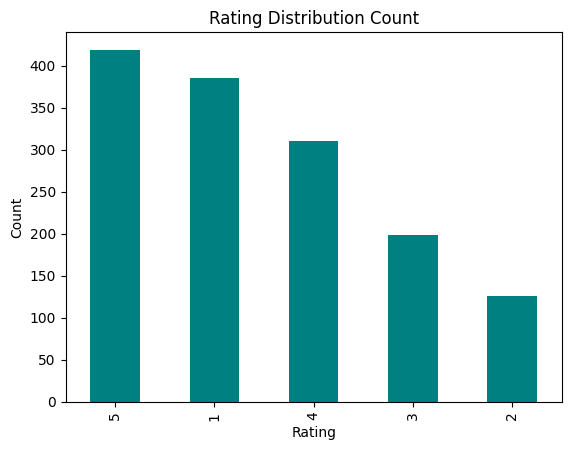

In [16]:
# Bar Plot to Visulaize the total counts of each rating

df['Rating'].value_counts().plot(kind='bar', color='teal')
plt.title('Rating Distribution Count')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [17]:
#Finding the % distribution of each rating

print(f'Rating value count - Percentage Distribution: \n{round(df['Rating'].value_counts()/df.shape[0]*100,2)}')

Rating value count - Percentage Distribution: 
Rating
5    29.10
1    26.81
4    21.53
3    13.82
2     8.75
Name: count, dtype: float64


In [18]:
# Class Balance Analysis
balance = df['Sentiment'].value_counts(normalize=True) * 100
print("Class Distribution (%):")
print(balance)

Class Distribution (%):
Sentiment
Positive    50.625000
Negative    35.555556
Neutral     13.819444
Name: proportion, dtype: float64


C:\Users\Jawad\AppData\Local\Temp\ipykernel_20780\3538896544.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment', data=df, palette='coolwarm', order=['Positive', 'Neutral', 'Negative'])


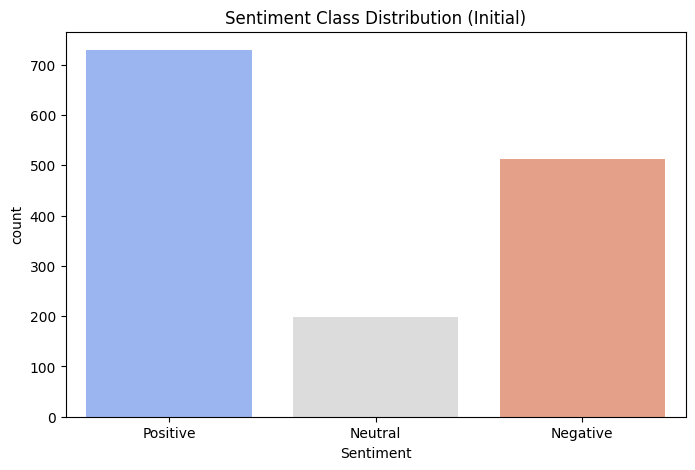

In [19]:
# Visualization: Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='Sentiment', data=df, palette='coolwarm', order=['Positive', 'Neutral', 'Negative'])
plt.title('Sentiment Class Distribution (Initial)')
plt.show()

**3. Textual Statistical Analysis & Ooutlier Removal**

In [20]:
df['word_count'] = df['Review_Text'].apply(lambda x: len(x.split()))
df['char_count'] = df['Review_Text'].apply(lambda x: len(x))

In [21]:
# Corpus Metrics
print(f"Avg Word Count: {df['word_count'].mean():.2f}")
print(f"Max Word Count: {df['word_count'].max()}")

Avg Word Count: 52.89
Max Word Count: 385


In [22]:
# For reference and can be used in data modelling section
# Punctuation Density (Emotional Intensity)
df['exclam_count'] = df['Review_Text'].apply(lambda x: x.count('!'))
df['ques_count'] = df['Review_Text'].apply(lambda x: x.count('?'))

In [23]:
# OUTLIER IDENTIFICATION & REMOVAL (IQR Method)
Q1 = df['word_count'].quantile(0.25)
Q3 = df['word_count'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [24]:
outlier_count = len(df[(df['word_count'] < lower_bound) | (df['word_count'] > upper_bound)])
print(f"Outliers Identified (by word count): {outlier_count}")

Outliers Identified (by word count): 94


In [25]:
# Removing Outliers
df_cleaned = df[(df['word_count'] >= lower_bound ) & (df['word_count'] <= upper_bound)].copy()
print(f"Dataset size after outlier removal: {len(df_cleaned)}")

Dataset size after outlier removal: 1346


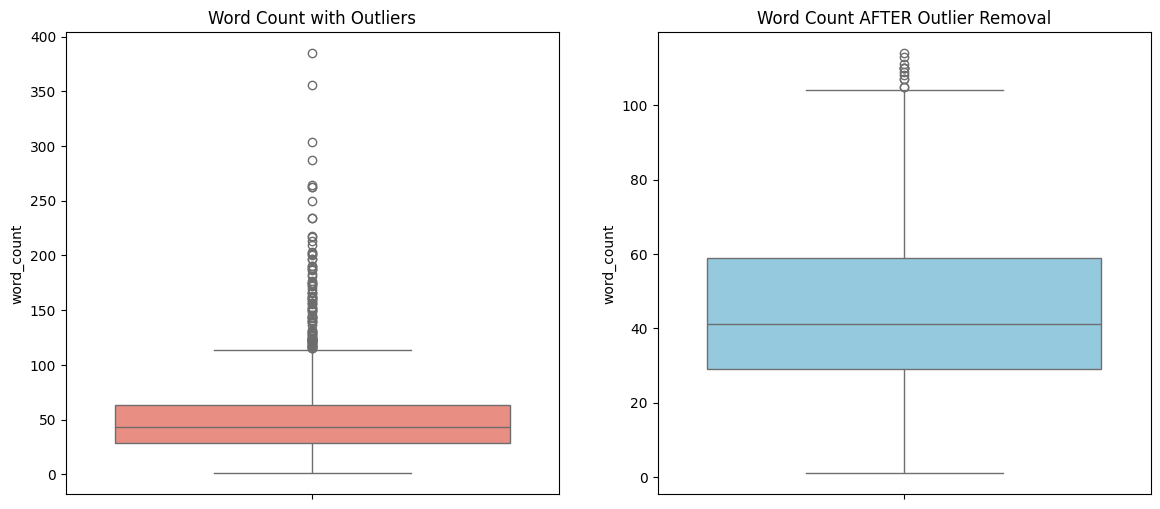

In [26]:
# Visualization :
# 1.

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['word_count'], color='salmon')
plt.title('Word Count with Outliers')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_cleaned['word_count'], color='skyblue')
plt.title('Word Count AFTER Outlier Removal')
plt.show()

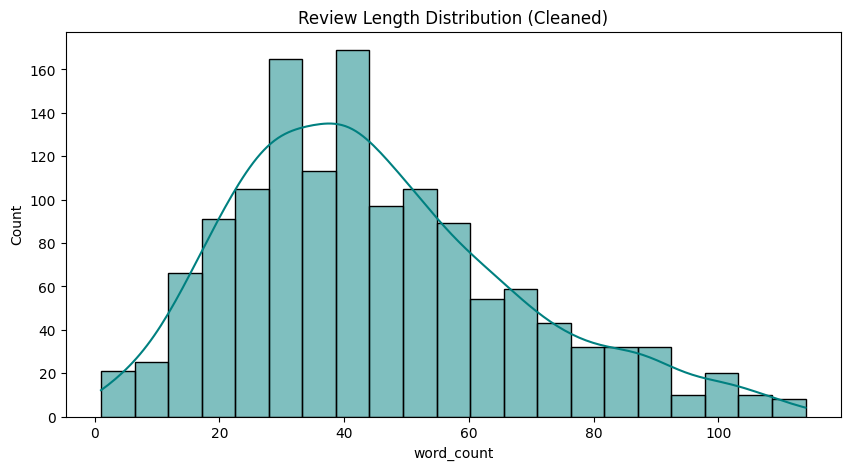

In [27]:
# 2. Histogram

plt.figure(figsize=(10, 5))
sns.histplot(df_cleaned['word_count'], kde=True, color='teal')
plt.title('Review Length Distribution (Cleaned)')
plt.show()

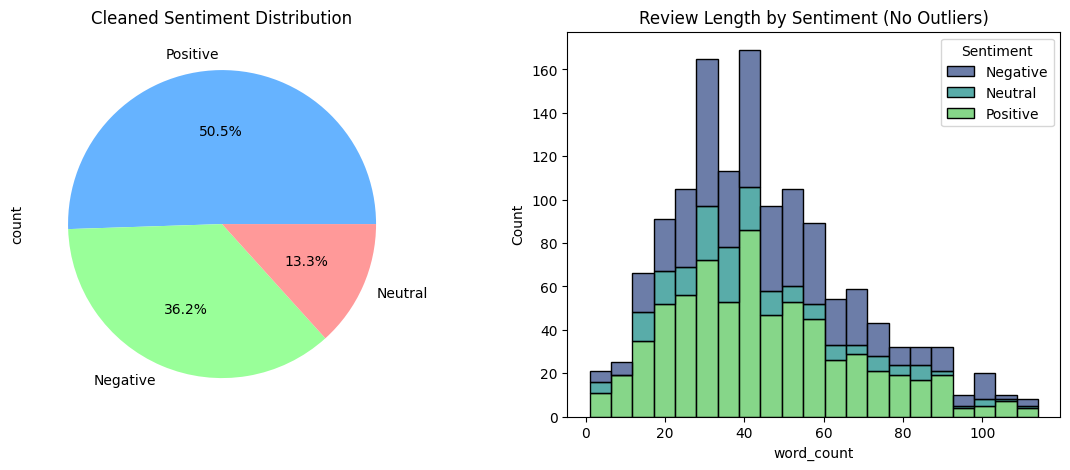

In [28]:
# 3. Pie chart and Bar_chat
# CLASS BALANCE & TEXT DISTRIBUTION

plt.figure(figsize=(14, 5))

# Sentiment Balance
plt.subplot(1, 2, 1)
df_cleaned['Sentiment'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#66b3ff','#99ff99','#ff9999'])
plt.title('Cleaned Sentiment Distribution')

# Length Distribution
plt.subplot(1, 2, 2)
sns.histplot(data=df_cleaned, x='word_count', hue='Sentiment', multiple="stack", palette='viridis')
plt.title('Review Length by Sentiment (No Outliers)')
plt.show()

**4. Word Frequency & Semantic Exploration**

In [29]:
pip install "numpy<2.0"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
def show_wordcloud(text, title):
    wc = WordCloud(width=800, height=400, background_color='white', stopwords=STOP_WORDS).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc.to_image(), interpolation='bilinear')  # ← .to_image() fixes the numpy conflict
    plt.axis('off')
    plt.title(title)
    plt.show()

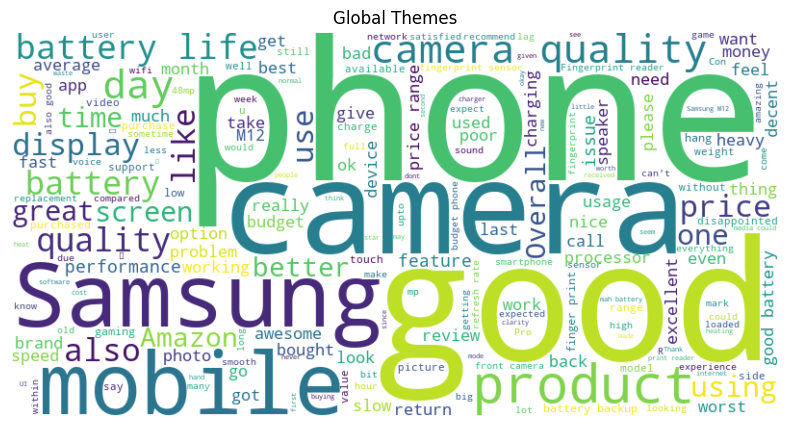

In [31]:
# Visuals of Global WordCloud
show_wordcloud(" ".join(df_cleaned['Review_Text']), "Global Themes")

In [32]:
# N-Gram Extraction (Top 10 Bigrams)
def get_ngrams(text_list, n=2):
    all_words = " ".join(text_list).lower()
    tokens = [w for w in nltk.word_tokenize(all_words) if w.isalnum() and w not in STOP_WORDS]
    n_grams = ngrams(tokens, n)
    return Counter(n_grams).most_common(10)

In [33]:
# Important when we used N-Gram Extraction - as it helps to correctly identify the boundaries between two worrds (e.g: "not happy")
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Jawad\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [34]:
print("Top 10 Bigrams (Context):", get_ngrams(df_cleaned['Review_Text'], 2))

Top 10 Bigrams (Context): [(('camera', 'quality'), 211), (('battery', 'life'), 208), (('quality', 'good'), 75), (('price', 'range'), 74), (('good', 'battery'), 70), (('good', 'phone'), 62), (('battery', 'backup'), 58), (('finger', 'print'), 56), (('phone', 'good'), 55), (('good', 'camera'), 51)]


In [35]:
df_cleaned.to_csv("cleaned_nlp_dataset.csv", index=False)

# Pre-processing and Feature Engineering

**Preprocessing, Feature Insights & Data Balancing**

In [36]:
# Feature Engineering: Shouting (All Caps)
df_cleaned['shouting_ratio'] = df_cleaned['Review_Text'].apply(
    lambda x: sum(1 for c in x if c.isupper()) / len(x) if len(x) > 0 else 0
)   

In [37]:
# DATA BALANCING (Upsampling Minority Classes)
#  We balance the data to match the majority class count
majority_class = df_cleaned[df_cleaned.Sentiment == 'Positive']
neutral_class = df_cleaned[df_cleaned.Sentiment == 'Neutral']
negative_class = df_cleaned[df_cleaned.Sentiment == 'Negative']

In [38]:
neutral_upsampled = resample(neutral_class, replace=True, n_samples=len(majority_class), random_state=42)
negative_upsampled = resample(negative_class, replace=True, n_samples=len(majority_class), random_state=42)

In [39]:
df_balanced = pd.concat([majority_class, neutral_upsampled, negative_upsampled])
print(f"Balanced Dataset Size: {len(df_balanced)}")

Balanced Dataset Size: 2040


In [40]:
print("New Class Counts:\n", df_balanced.Sentiment.value_counts())

New Class Counts:
 Sentiment
Positive    680
Neutral     680
Negative    680
Name: count, dtype: int64


In [41]:
# TEXT CLEANING FUNCTION
# Lemmatizer converts words to their base/root form (e.g., "running" → "run")
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Convert input to string and lowercase (standardization)
    text = str(text).lower()
    
    # Remove URLs (e.g., http://..., https://..., www...)
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Remove HTML tags (e.g., <br>, <p>)
    text = re.sub(r'<.*?>', '', text)
    
    # Remove special characters, numbers, punctuation
    # Keep only lowercase alphabets and spaces
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Tokenize text (split sentence into words)
    tokens = text.split()
    
    # Remove stopwords and short words, then apply lemmatization
    tokens = [
        lemmatizer.lemmatize(word)   # convert word to root form
        for word in tokens
        if word not in STOP_WORDS    # remove common words like 'the', 'is'
        and len(word) > 2            # remove very short words (length <= 2)
    ]
    
    # Join cleaned tokens back into a single string
    return ' '.join(tokens)

# APPLY CLEANING TO DATASET
# Apply the clean_text function to 'Review_Text' column
# and store results in a new column 'Clean_Text'
df_balanced['Clean_Text'] = df_balanced['Review_Text'].apply(clean_text)



# DISPLAY SAMPLE OUTPUT
# Print first 3 cleaned reviews to verify preprocessing
print(df_balanced['Clean_Text'].head(3))

2     got mobile launch datebattery must appreciated...
14    unboxed phoneseems better one price segment no...
19    perfect phone good speed decent spec outstandi...
Name: Clean_Text, dtype: object


## Model Building


In [42]:
# IMPORT REQUIRED LIBRARIES
from sklearn.feature_extraction.text import TfidfVectorizer  # Converts text data into numerical form using TF-IDF (important for ML models)
from sklearn.linear_model import LogisticRegression  
from sklearn.naive_bayes import MultinomialNB  
from sklearn.svm import LinearSVC  
from sklearn.ensemble import RandomForestClassifier  
from sklearn.model_selection import train_test_split  
from sklearn.model_selection import cross_val_score, StratifiedKFold  

# Evaluation metrics to measure model performance
from sklearn.metrics import (
    accuracy_score,            # Measures overall accuracy
    classification_report,     # Shows precision, recall, F1-score
    confusion_matrix,          # Displays prediction errors
    ConfusionMatrixDisplay,    # Visualizes confusion matrix
    f1_score                   # Harmonic mean of precision & recall
)

# Used for hyperparameter tuning (finding best model parameters)
from sklearn.model_selection import GridSearchCV  
from sklearn.pipeline import Pipeline  

# TEXT PREPROCESSING TOOLS
# Set of common English stopwords (e.g., "the", "is", "and") to remove noise
STOP_WORDS = set(stopwords.words('english'))  

# Lemmatizer converts words to their base/root form (e.g., "running" → "run")
lemmatizer = WordNetLemmatizer()

# Train & Test Split

In [43]:
# Train-Test Split

# Features (input text) and target labels (sentiment)
X = df_balanced['Clean_Text']
y = df_balanced['Sentiment']

# Split data into training (80%) and testing (20%) sets
# stratify=y ensures class distribution is maintained in both sets
# random_state=42 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Print number of samples in train and test sets
print(f'Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}')

Train: 1632  |  Test: 408


In [44]:
# TF-IDF Vectorization

# Initialize TF-IDF vectorizer with optimized parameters
tfidf = TfidfVectorizer(
    max_features = 8000,      # limit vocabulary size to top 8000 words
    ngram_range  = (1, 2),    # use unigrams and bigrams (e.g., "not good")
    sublinear_tf = True,      # apply log scaling to term frequency
    min_df       = 2,         # ignore words that appear in less than 2 documents
    max_df       = 0.95       # ignore words that appear in more than 95% of documents
)

# Fit TF-IDF on training data and transform it into numerical vectors
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform test data using the same fitted vectorizer
X_test_tfidf = tfidf.transform(X_test)

# Print shape of the resulting sparse matrices
print(f'Matrix shape — Train: {X_train_tfidf.shape} | Test: {X_test_tfidf.shape}')

Matrix shape — Train: (1632, 8000) | Test: (408, 8000)


# 1. Logistic Regression

In [45]:
# Logistic Regression

lr_model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)

# Train
lr_model.fit(X_train_tfidf, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test_tfidf)

# Evaluation
acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr  = f1_score(y_test, y_pred_lr, average='weighted')

print(f'Accuracy: {acc_lr:.4f}')
print(f'F1 Score: {f1_lr:.4f}\n')

print(classification_report(
    y_test, y_pred_lr,
    target_names=['Negative', 'Neutral', 'Positive']
))

Accuracy: 0.8922
F1 Score: 0.8925

              precision    recall  f1-score   support

    Negative       0.90      0.92      0.91       136
     Neutral       0.94      0.89      0.91       136
    Positive       0.84      0.87      0.86       136

    accuracy                           0.89       408
   macro avg       0.89      0.89      0.89       408
weighted avg       0.89      0.89      0.89       408



# 2. Naive Bayes

In [46]:
# Naive Bayes

nb_model = MultinomialNB(alpha=0.1)

# Train
nb_model.fit(X_train_tfidf, y_train)

# Predict
y_pred_nb = nb_model.predict(X_test_tfidf)

# Evaluation
acc_nb = accuracy_score(y_test, y_pred_nb)
f1_nb  = f1_score(y_test, y_pred_nb, average='weighted')

print(f'Accuracy: {acc_nb:.4f}')
print(f'F1 Score: {f1_nb:.4f}\n')

print(classification_report(
    y_test, y_pred_nb,
    target_names=['Negative', 'Neutral', 'Positive']
))

Accuracy: 0.8603
F1 Score: 0.8629

              precision    recall  f1-score   support

    Negative       0.96      0.76      0.85       136
     Neutral       0.98      0.85      0.91       136
    Positive       0.72      0.97      0.83       136

    accuracy                           0.86       408
   macro avg       0.89      0.86      0.86       408
weighted avg       0.89      0.86      0.86       408



# 3. Linear SVM

In [47]:
# Linear SVM

svm_model = LinearSVC(C=1.0, max_iter=2000, random_state=42)

# Train
svm_model.fit(X_train_tfidf, y_train)

# Predict
y_pred_svm = svm_model.predict(X_test_tfidf)

# Evaluation
acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm  = f1_score(y_test, y_pred_svm, average='weighted')

print(f'Accuracy: {acc_svm:.4f}')
print(f'F1 Score: {f1_svm:.4f}\n')

print(classification_report(
    y_test, y_pred_svm,
    target_names=['Negative', 'Neutral', 'Positive']
))

Accuracy: 0.9118
F1 Score: 0.9121

              precision    recall  f1-score   support

    Negative       0.94      0.91      0.93       136
     Neutral       0.93      0.92      0.93       136
    Positive       0.87      0.90      0.88       136

    accuracy                           0.91       408
   macro avg       0.91      0.91      0.91       408
weighted avg       0.91      0.91      0.91       408



# 4. RANDOM FOREST

In [48]:
# Random Forest

rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

# Train
rf_model.fit(X_train_tfidf, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test_tfidf)

# Evaluation
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf  = f1_score(y_test, y_pred_rf, average='weighted')

print(f'Accuracy: {acc_rf:.4f}')
print(f'F1 Score: {f1_rf:.4f}\n')

print(classification_report(
    y_test, y_pred_rf,
    target_names=['Negative', 'Neutral', 'Positive']
))

Accuracy: 0.8848
F1 Score: 0.8862

              precision    recall  f1-score   support

    Negative       0.89      0.82      0.85       136
     Neutral       1.00      0.91      0.95       136
    Positive       0.79      0.93      0.85       136

    accuracy                           0.88       408
   macro avg       0.89      0.88      0.89       408
weighted avg       0.89      0.88      0.89       408



# Model Comparison 

In [49]:
# Train Models and Compare Performance

# Dictionary of models with their configurations
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'Naive Bayes'        : MultinomialNB(alpha=0.1),
    'Linear SVM'         : LinearSVC(C=1.0, max_iter=2000, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
}

results = []  # list to store model performance

# Loop through each model
for name, model in models.items():
    
    # Train the model on TF-IDF features
    model.fit(X_train_tfidf, y_train)
    
    # Predict on test data
    y_pred = model.predict(X_test_tfidf)
    
    # Calculate evaluation metrics
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    
    # Store results
    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Weighted F1': round(f1, 4)
    })
    
    # Print performance of each model
    print(f'{name:25s}  Accuracy: {acc:.4f}  |  Weighted F1: {f1:.4f}')

# Create a DataFrame and sort models based on F1 score (best model on top)
results_df = pd.DataFrame(results).sort_values('Weighted F1', ascending=False)

Logistic Regression        Accuracy: 0.8922  |  Weighted F1: 0.8925
Naive Bayes                Accuracy: 0.8603  |  Weighted F1: 0.8629
Linear SVM                 Accuracy: 0.9118  |  Weighted F1: 0.9121
Random Forest              Accuracy: 0.8848  |  Weighted F1: 0.8862


# BEST MODEL : Linear SVM ( Detailed Report)

In [50]:
# Best Model - Detailed Report

# Get the name of the best-performing model (highest F1 score)
best_name = results_df.iloc[0]['Model']

# Retrieve the corresponding trained model
best_model = models[best_name]

# Predict on test data using the best model
y_pred = best_model.predict(X_test_tfidf)

# Print best model name
print(f'Best model: {best_name}\n')

# Display detailed classification metrics (precision, recall, F1-score)
print(classification_report(
    y_test,
    y_pred,
    target_names=['Negative', 'Neutral', 'Positive']
))

Best model: Linear SVM

              precision    recall  f1-score   support

    Negative       0.94      0.91      0.93       136
     Neutral       0.93      0.92      0.93       136
    Positive       0.87      0.90      0.88       136

    accuracy                           0.91       408
   macro avg       0.91      0.91      0.91       408
weighted avg       0.91      0.91      0.91       408



In [51]:
# Define Pipeline (TF-IDF + SVM)

# Create a pipeline that combines text vectorization and model training
pipeline = Pipeline([
    
    # Convert raw text into TF-IDF feature vectors
    ('tfidf', TfidfVectorizer(
        sublinear_tf=True,   # apply log scaling to term frequency
        min_df=2,            # ignore rare words (appear in < 2 documents)
        max_df=0.95          # ignore very common words (appear in > 95% documents)
    )),
    
    # Apply Linear Support Vector Machine for classification
    ('svm', LinearSVC(
        max_iter=3000,       # increase iterations for better convergence
        random_state=42      # ensure reproducibility
    ))
])

In [52]:
# Hyperparameter Grid for Tuning

# Define parameter grid for GridSearchCV
param_grid = {
    
    # Number of features (vocabulary size) to consider in TF-IDF
    'tfidf__max_features': [8000, 15000, 20000],
    
    # N-gram range: unigrams, bigrams, trigrams
    'tfidf__ngram_range': [(1, 1), (1, 2), (1, 3)],
    
    # Regularization parameter for SVM (controls model complexity)
    'svm__C': [0.1, 0.5, 1.0, 5.0, 10.0],
}

In [53]:
# Grid Search for Hyperparameter Tuning

# Initialize GridSearchCV to find the best parameter combination
grid_search = GridSearchCV(
    estimator=pipeline,   # pipeline containing TF-IDF + SVM
    param_grid=param_grid,  # hyperparameters to tune
    
    # Use Stratified K-Fold to maintain class distribution in each fold
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    
    scoring='f1_weighted',  # evaluation metric (best for imbalanced data)
    
    n_jobs=1,   # run on a single core (prevents BrokenProcessPool error)
    verbose=1   # display progress during training
)   

# Train models for all parameter combinations
grid_search.fit(X_train, y_train)

# Print best parameters found
print(f'\nBest Parameters : {grid_search.best_params_}')

# Print best cross-validation F1 score
print(f'Best CV F1 Score: {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 45 candidates, totalling 225 fits

Best Parameters : {'svm__C': 1.0, 'tfidf__max_features': 8000, 'tfidf__ngram_range': (1, 2)}
Best CV F1 Score: 0.9075


# Evaluate Best Model on Test Set

In [54]:
# Evaluate Best Model on Test Set

# Get the best model (pipeline with best TF-IDF + SVM parameters)
best_svm = grid_search.best_estimator_

# Predict on test data (raw text, pipeline handles vectorization internally)
y_pred = best_svm.predict(X_test)

# Calculate evaluation metrics
acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='weighted')

# Print accuracy and F1 score
print(f'Test Accuracy : {acc:.4f}')
print(f'Test F1 Score : {f1:.4f}')
print()

# Display detailed classification report
print(classification_report(
    y_test,
    y_pred,
    target_names=['Negative', 'Neutral', 'Positive']
))

Test Accuracy : 0.9118
Test F1 Score : 0.9121

              precision    recall  f1-score   support

    Negative       0.94      0.91      0.93       136
     Neutral       0.93      0.92      0.93       136
    Positive       0.87      0.90      0.88       136

    accuracy                           0.91       408
   macro avg       0.91      0.91      0.91       408
weighted avg       0.91      0.91      0.91       408



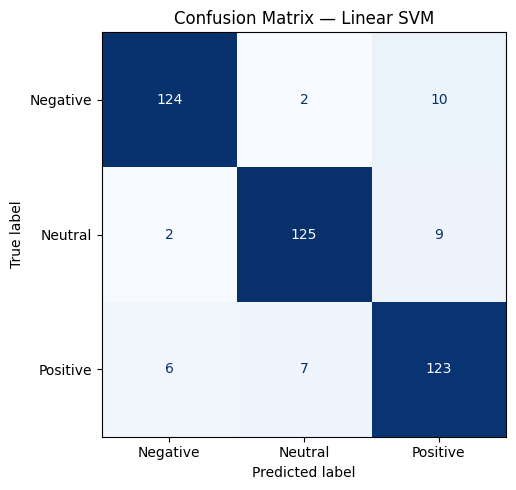

In [55]:
# Confusion Matrix

# Compute confusion matrix using true and predicted labels
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=['Negative', 'Neutral', 'Positive']
)

# Create display object with class labels
disp = ConfusionMatrixDisplay(
    cm,
    display_labels=['Negative', 'Neutral', 'Positive']
)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)

# Set title with best model name
ax.set_title(f'Confusion Matrix — {best_name}')

# Adjust layout and display plot
plt.tight_layout()
plt.show()

# MODEL COMPARISON CHART

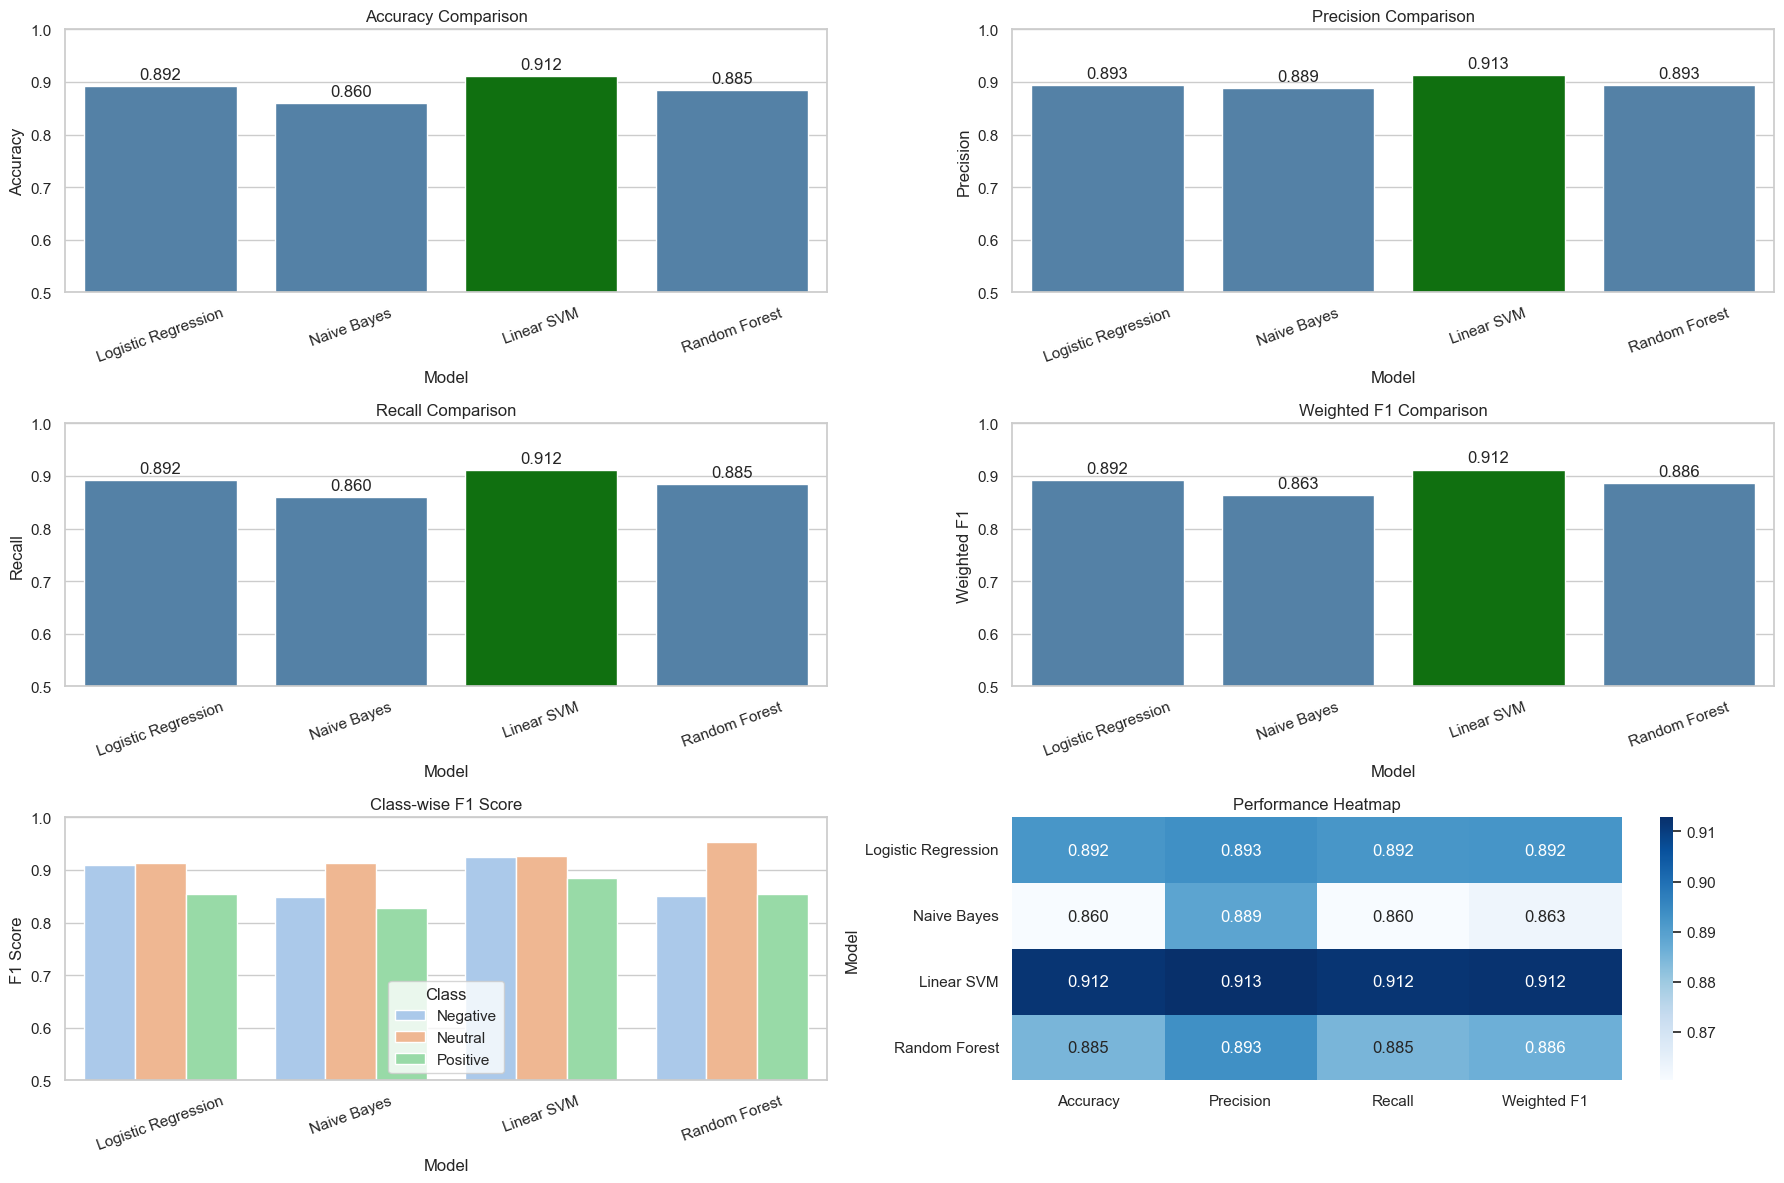

In [56]:
import warnings
warnings.filterwarnings('ignore')  # hide all warnings

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report


# STEP 1: STORE PREDICTIONS
predictions = {
    'Logistic Regression': y_pred_lr,  
    'Naive Bayes': y_pred_nb,
    'Linear SVM': y_pred_svm,
    'Random Forest': y_pred_rf
}


# STEP 2: EXTRACT METRICS
results = []
class_f1 = []

# Detect class labels dynamically
classes = sorted(list(set(y_test)))

for name, y_pred in predictions.items():
    
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    
    # Overall metrics
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': report['weighted avg']['precision'],
        'Recall': report['weighted avg']['recall'],
        'Weighted F1': report['weighted avg']['f1-score']
    })
    
    # Class-wise F1 dynamically
    cf_dict = {'Model': name}
    for c in classes:
        cf_dict[str(c)] = report[str(c)]['f1-score']
    class_f1.append(cf_dict)

results_df = pd.DataFrame(results)
class_f1_df = pd.DataFrame(class_f1)


# STEP 3: VISUALIZATION
sns.set(style="whitegrid")
fig = plt.figure(figsize=(18, 12))

# Color mapping: Linear SVM green, others blue
colors = ['green' if m=='Linear SVM' else 'steelblue' for m in results_df['Model']]

# ---- Multi-metric plots ----
metrics = ['Accuracy', 'Precision', 'Recall', 'Weighted F1']
for i, metric in enumerate(metrics):
    ax = plt.subplot(3, 2, i+1)
    sns.barplot(data=results_df, x='Model', y=metric, ax=ax, palette=colors)
    ax.set_ylim(0.5, 1.0)
    ax.set_title(f'{metric} Comparison')
    ax.tick_params(axis='x', rotation=20)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=3)

# ---- Class-wise F1 ----
class_f1_melted = class_f1_df.melt(id_vars='Model', var_name='Class', value_name='F1 Score')
ax5 = plt.subplot(3, 2, 5)

# Assign colors for class-wise F1 bars
palette_class = {m: ('green' if m=='Linear SVM' else 'steelblue') for m in class_f1_df['Model'].values}

sns.barplot(data=class_f1_melted, x='Model', y='F1 Score', hue='Class', ax=ax5, palette='pastel')
ax5.set_ylim(0.5, 1.0)
ax5.set_title('Class-wise F1 Score')
ax5.tick_params(axis='x', rotation=20)

# ---- Heatmap ----
ax6 = plt.subplot(3, 2, 6)
sns.heatmap(results_df.set_index('Model'), annot=True, fmt=".3f", cmap="Blues", ax=ax6)
ax6.set_title("Performance Heatmap")

plt.tight_layout()
plt.show()

# Cross Validation

In [57]:
# Cross Validation
# Transform entire dataset using the already fitted TF-IDF vectorizer
X_all = tfidf.transform(df_balanced['Clean_Text'])

# Target labels
y_all = df_balanced['Sentiment']

# Perform cross-validation on the best model
cv_scores = cross_val_score(
    best_model, X_all, y_all,
    
    # Use Stratified K-Fold to maintain class balance in each fold
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    
    scoring='f1_weighted',  # evaluation metric
    n_jobs=1                # single core (safe execution)
)

# Print individual fold scores
print(f'CV F1 scores : {cv_scores.round(4)}')

# Print mean and standard deviation of scores
print(f'Mean ± Std   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

CV F1 scores : [0.9293 0.9338 0.8873 0.9212 0.9459]
Mean ± Std   : 0.9235 ± 0.0198


# SAVING THE MODEL

In [58]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: joblib in c:\users\jawad\appdata\local\programs\python\python312\lib\site-packages (1.4.2)




[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [59]:
#  SAVE MODEL & VECTORIZER 
import joblib
joblib.dump(best_model, 'sentiment_model.pkl')
joblib.dump(tfidf,      'tfidf_vectorizer.pkl')

print(f'✓ Saved: sentiment_model.pkl  ({best_name})')
print('✓ Saved: tfidf_vectorizer.pkl')

✓ Saved: sentiment_model.pkl  (Linear SVM)
✓ Saved: tfidf_vectorizer.pkl


# OVERALL RESULT OF ALL THE MODELS

| Rank | Model                   | Accuracy | F1 Score | Negative (F1) | Neutral (F1) | Positive (F1) |
| ---- | ----------------------- | -------- | -------- | ------------- | ------------ | ------------- |
| 🥇 1 | **Linear SVM**          | 0.9118   | 0.9121   | 0.93          | 0.93         | 0.88          |
| 🥈 2 | **Logistic Regression** | 0.8922   | 0.8925   | 0.91          | 0.91         | 0.86          |
| 🥉 3 | **Random Forest**       | 0.8848   | 0.8862   | 0.85          | 0.95         | 0.85          |
| 4    | **Naive Bayes**         | 0.8603   | 0.8629   | 0.85          | 0.91         | 0.83          |
